# 05 · Capture sites and LMD wells

Deep Visual Proteomics captures **Pu.1⁺ cells** per capture site (section × compartment) by laser
microdissection and measures them by mass spectrometry. This notebook summarises how many Pu.1⁺ cells
each capture site offers, how many were selected for a well, and where they are.

Compartments: in lesion sections `core`, `rim`, and rings outside the lesion edge at 0–10 %, 10–20 %,
20–40 %, 40–60 % and >60 % of the section radius (the last two reach deep into the tissue); in control
sections the manual `GM` / `WM` regions. Manual
annotation compartments (GM, WM, vbo, manual core, unannotated) are listed for every section as well.
Meningeal cells and the buffer around them are never captured (see *Meninges, buffer and the edge
exclusion*).

In [1]:
import os, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
os.chdir(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
%config InlineBackend.figure_format = 'jpeg'   # image-heavy notebooks: keep files small
plt.rcParams["figure.dpi"] = 80
from lesionseg import report as R
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 120)
RUN_DIR = "outputs/sdata"
runs = R.load_runs(RUN_DIR)
print("scenes:", [r.name for r in runs])

scenes: ['CML_1 scene 0', 'CML_2_rescan scene 0', 'CML_metal scene 0', 'CML_metal scene 1']


## Pooled over all sections

In [2]:
coh = Path(RUN_DIR) / "cohort"
pooled = pd.read_csv(coh / "capture_sites_pooled.csv")
cols = ["lesion_section", "kind", "compartment", "n_sections", "n_cells_all", "n_pu1_raw", "n_pu1_eligible", "area_pu1_eligible_um2", "n_selected", "area_selected_um2", "frac_pu1"]
pooled[pooled.compartment != "all"][cols].round(3)

,lesion_section,kind,compartment,n_sections,n_cells_all,n_pu1_raw,n_pu1_eligible,area_pu1_eligible_um2,n_selected,area_selected_um2,frac_pu1
0,False,manual annotation,manual:GM,10,27387,6168,6161,201552.350,1666,53038.140,0.225
1,False,manual annotation,manual:WM,10,13926,1935,1778,50721.349,976,26130.666,0.139
2,False,manual annotation,manual:core,10,0,0,0,0.000,0,0.000,NaN
3,False,manual annotation,manual:unannotated,10,35601,6551,3773,113887.588,0,0.000,0.184
4,False,manual annotation,manual:vbo,10,501,50,0,0.000,0,0.000,0.100
5,False,well group,GM,10,27357,6163,6159,201487.668,1666,53038.140,0.225
6,False,well group,WM,10,12954,1830,1772,50596.742,976,26130.666,0.141
8,True,manual annotation,manual:GM,8,0,0,0,0.000,0,0.000,NaN
9,True,manual annotation,manual:WM,8,0,0,0,0.000,0,0.000,NaN
10,True,manual annotation,manual:core,8,21898,10677,9368,273617.429,1705,48658.632,0.488


## Per section (Pu.1⁺ cells eligible for capture)

In [3]:
cap = pd.read_csv(coh / "capture_sites_by_section.csv")
wg = cap[cap.kind == "well group"]
display(wg.pivot_table(index=["sample", "scene", "section", "lesion_section"], columns="compartment", values="n_pu1_eligible", aggfunc="sum", fill_value=0).astype(int))
ma = cap[cap.kind == "manual annotation"]
display(ma.pivot_table(index=["sample", "scene", "section", "lesion_section"], columns="compartment", values="n_pu1_raw", aggfunc="sum", fill_value=0).astype(int))

compartment                                  GM   WM  core   rim  ring_0_10  ring_10_20  ring_20_40  ring_40_60  ring_60_plus
sample       scene section  lesion_section                                                                                   
CML_1        0     OS1_2_   False           159   40     0     0          0           0           0           0             0
                   OS1_2_C  False           312   60     0     0          0           0           0           0             0
                   OS1_2_L  False           207   76     0     0          0           0           0           0             0
                   P2_3_C   True              0    0   707   544        624         476         810         259             3
                   P2_3_L   True              0    0  1141   277        231         205         426         329             3
                   P2_3_T   True              0    0  1714   319        227         205         312         215            23
                   R1_3_C   False           898  259     0     0          0           0           0           0             0
                   R1_3_L   True              0    0    15    86         67          84         249         202           604
                   R1_3_T   True              0    0    21    51         66          61         201         212           126
CML_2_rescan 0     CFA_L2_C False           334   47     0     0          0           0           0           0             0
                   CFA_L2_L False           303   42     0     0          0           0           0           0             0
                   CFA_L2_T False           130   28     0     0          0           0           0           0             0
                   P3_1_C   True              0    0   563   813        362         249         460         232            12
                   P3_1_L   False           271  241     0     0          0           0           0           0             0
                   P3_1_T   True              0    0   247   200        118          87         183         223           224
                   R1_2_C   False             0    0     0     0          0           0           0           0             0
                   R1_2_L   False           254  338     0     0          0           0           0           0             0
                   R1_2_T   True              0    0   924  1213        784         437         574          73             0
CML_metal    0     OS1_2_   False           161   24     0     0          0           0           0           0             0
                   OS1_2_C  False           602   61     0     0          0           0           0           0             0
                   OS1_2_L  False           175   23     0     0          0           0           0           0             0
                   P2_3_C   True              0    0   328   493        254         233         448         468           116
                   P2_3_L   True              0    0   668   273        260         305         402         392            62
                   P2_3_T   True              0    0  1046   233        190         119         314         155            69
                   R1_3_C   False           988  166     0     0          0           0           0           0             0
                   R1_3_L   True              0    0     0    53         75          41         183         190           661
                   R1_3_T   True              0    0     0    11         29          25         140         227           276
             1     CFA_L2_C False           284   47     0     0          0           0           0           0             0
                   CFA_L2_L False           435   20     0     0          0           0           0           0             0
                   CFA_L2_T False           133   12     0     0          0           0       

compartment                                 manual:GM  manual:WM  manual:core  manual:unannotated  manual:vbo
sample       scene section  lesion_section                                                                   
CML_1        0     OS1_2_   False                 159         47            0                  57           0
                   OS1_2_C  False                 312         64            0                 107           4
                   OS1_2_L  False                 209         79            0                 201           2
                   P2_3_C   True                    0          0          708                3537           0
                   P2_3_L   True                    0          0         1082                2001          28
                   P2_3_T   True                    0          0         1442                2288          10
                   R1_3_C   False                 898        272            0                 873          12
                   R1_3_L   True                    0          0          172                1531           0
                   R1_3_T   True                    0          0          172                 880           5
CML_2_rescan 0     CFA_L2_C False                 336         55            0                  66           2
                   CFA_L2_L False                 303         55            0                  83           0
                   CFA_L2_T False                 130         36            0                  43           1
                   P3_1_C   True                    0          0         1003                2378          11
                   P3_1_L   False                 271        259            0                 391           2
                   P3_1_T   True                    0          0          418                1243           3
                   R1_2_C   False                   0          0            0                 120           0
                   R1_2_L   False                 254        383            0                 541           8
                   R1_2_T   True                    0          0         1869                2827          14
CML_metal    0     OS1_2_   False                 161         30            0                 145           0
                   OS1_2_C  False                 602         65            0                 189           7
                   OS1_2_L  False                 175         30            0                 523           0
                   P2_3_C   True                    0          0          394                2644           0
                   P2_3_L   True                    0          0          640                2165           0
                   P2_3_T   True                    0          0          606                2365           0
                   R1_3_C   False                 988        177            0                 777           6
                   R1_3_L   True                    0          0          160                1466           0
                   R1_3_T   True                    0          0          144                 838           3
             1     CFA_L2_C False                 284         53            0                 574           1
                   CFA_L2_L False                 438         23            0                 359           2
                   CFA_L2_T False                 135         15            0                  53           3
                   P3_1_C   True                    0          0          313                3796          11
                   P3_1_L   False                 166        123            0                 409           0
                   P3_1_T   True                    0          0          467                1408           0
                   R1_2_C   False                   0          0            0                  18           0
                   R1_2_L   False       

## Per animal

In [4]:
ba = pd.read_csv(coh / "capture_sites_by_animal.csv")
ba[ba.compartment != "all"].pivot_table(index=["animal", "lesion_section"], columns="compartment", values="n_pu1_eligible", aggfunc="sum", fill_value=0).astype(int)

compartment              GM   WM  core  manual:GM  manual:WM  manual:core  manual:unannotated  manual:vbo   rim  ring_0_10  ring_10_20  ring_20_40  ring_40_60  ring_60_plus
animal lesion_section                                                                                                                                                       
CFA_L2 False           1619  196     0       1621        197            0                 842           0     0          0           0           0           0             0
OS1_2  False           1616  284     0       1616        285            0                 817           0     0          0           0           0           0             0
P2_3   True               0    0  5604          0          0         4324               11553           0  2139       1786        1543        2712        1818           276
P3_1   False            437  360     0        437        360            0                 536           0     0          0           0           0           0             0
       True               0    0  1746          0          0         1994                6486           0  1993        975         739        1417        1064           540
R1_2   False            601  507     0        601        510            0                 789           0     0          0           0           0           0             0
       True               0    0  2576          0          0         2696                6622           0  2472       1788        1041        1250         192             0
R1_3   False           1886  425     0       1886        426            0                 789           0     0          0           0           0           0             0
       True               0    0    36          0          0          354                3602           0   201        237         211         773         831          1667

## Meninges, buffer and the edge exclusion

The meninges boundary is placed per location (`lesionseg.meninges`, `parenchyma.method: adaptive`):

* **meninges** – the outer 10 µm of the true surface (outermost nuclei), thin flaps / roots, and very
  compact surface-connected infiltrate (nuclei touching; nuclear area fraction above the 99.9th percentile
  of deep tissue), up to 80 µm deep;
* **buffer** – 10 µm inward of the meninges (and any cell within 6 µm of a meningeal cell): never
  collected, so meninges and lesion pools never touch;
* **manual lesion cores are protected** – nothing inside the collaborator's CORE polygons is ever
  meninges or buffer; where a core meets the meninges the buffer is carved from the meningeal side.
  Calibration on these scenes: without this, nuclear packing alone would call 7 % (99.9th percentile) to
  23 % (99th) of manual-core cells meninges – dense lymphocyte-rich subpial lesion looks like swollen
  meninges.

Lesion zones, wells and reactions are clipped to the parenchyma. On top of that, wells and reactions
skip cells within `edge_exclusion_um` of the section edge. That margin used to be 100 µm (the
collaborator's well protocol) and was the main thing keeping subpial lesion cells out; with meninges and
buffer excluded per cell it is now 40 µm, keeping off the damaged cut edge (25 µm let collected cells run
ragged up to the surface). The table below shows
what each margin would make available.

In [5]:
surf = R.surface_summary(runs)
display(Markdown(f"**Manual-core cells in meninges or buffer: {int(surf.manual_core_cells_in_meninges_or_buffer.sum())}** (must be 0)"))
display(surf.groupby("lesion_section")[[c for c in surf.columns if c.startswith("pu1_")]].sum())
display(surf.set_index(["scene", "section"]))

**Manual-core cells in meninges or buffer: 0** (must be 0)

,pu1_meninges,pu1_buffer,pu1_parenchyma,pu1_lesion_zone_within_100um_of_edge
lesion_section,,,,
False,1664,735,12305,0
True,5359,2649,40581,9483


lesion_section  pu1_meninges  pu1_buffer  pu1_parenchyma  manual_core_cells_in_meninges_or_buffer  pu1_lesion_zone_within_100um_of_edge  max_meninges_depth_um
scene                section                                                                                                                                                                 
CML_1 scene 0        OS1_2_             False            11           6             246                                        0                                     0                   21.6
                     OS1_2_C            False            34           6             447                                        0                                     0                   92.3
                     OS1_2_L            False            84          40             367                                        0                                     0                   56.8
                     P2_3_C              True           471         198            3576                                        0                                   728                   33.9
                     P2_3_L              True            74          92            2945                                        0                                   751                   43.7
                     P2_3_T              True           192         234            3314                                        0                                   955                   50.7
                     R1_3_C             False           246         146            1663                                        0                                     0                   74.5
                     R1_3_L              True           125         127            1451                                        0                                    93                   21.4
                     R1_3_T              True            81         109             867                                        0                                   187                   37.7
CML_2_rescan scene 0 CFA_L2_C           False            23          12             424                                        0                                     0                   28.5
                     CFA_L2_L           False            14           8             419                                        0                                     0                   68.2
                     CFA_L2_T           False            10           2             198                                        0                                     0                   45.7
                     P3_1_C              True           363         172            2857                                        0                                   884                   79.8
                     P3_1_L             False            47          40             836                                        0                                     0                   32.8
                     P3_1_T              True           157         114            1393                                        0                                   265                   39.5
                     R1_2_C             False            66           5              49                                        0                                     0                  111.8
                     R1_2_L             False           161          99             926                                        0                                     0                   67.6
                     R1_2_T              True           232         193            4285                                        0                                  1020                   63.7
CML_metal scene 0    OS1_2_             False            31           8             297                                        0                                     0                   61.1
                     OS1_2_C            F

### What the edge exclusion costs: Pu.1⁺ parenchyma cells available per lesion compartment

In [6]:
display(R.edge_exclusion_sweep(runs))

compartment,core,rim,peri,deep
edge_exclusion_um,,,,
100,6902,4205,5118,4316
75,8453,5009,5563,4522
50,9683,6179,6214,4767
40,9962,6805,6485,4893
25,10202,7598,6953,5027
0,10236,7724,7027,5037


### Where the meninges are thickest (raw image left, tiers right)

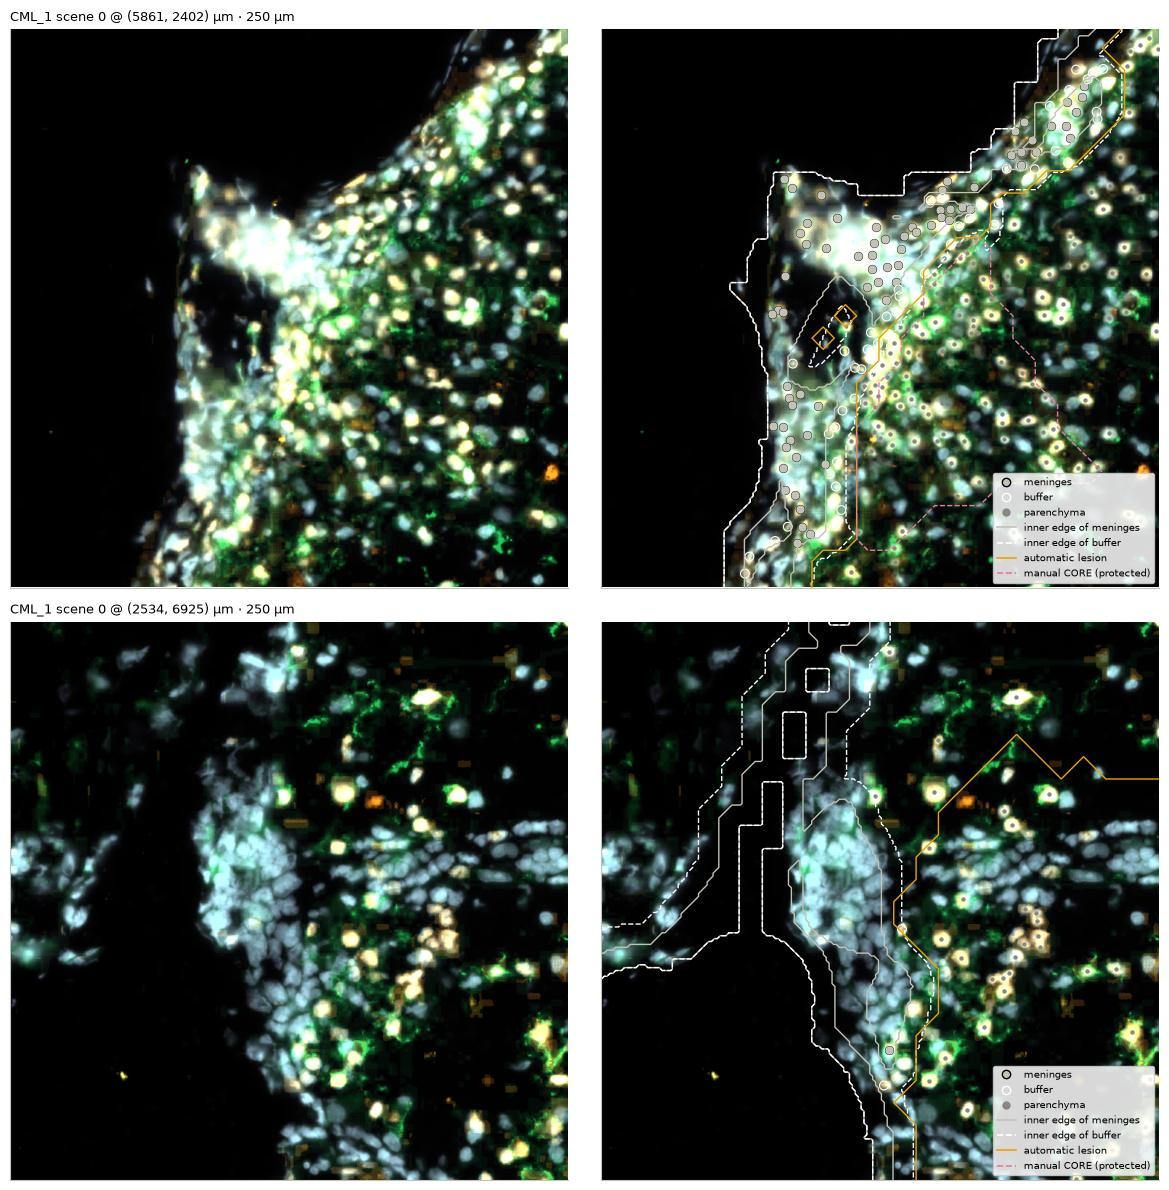

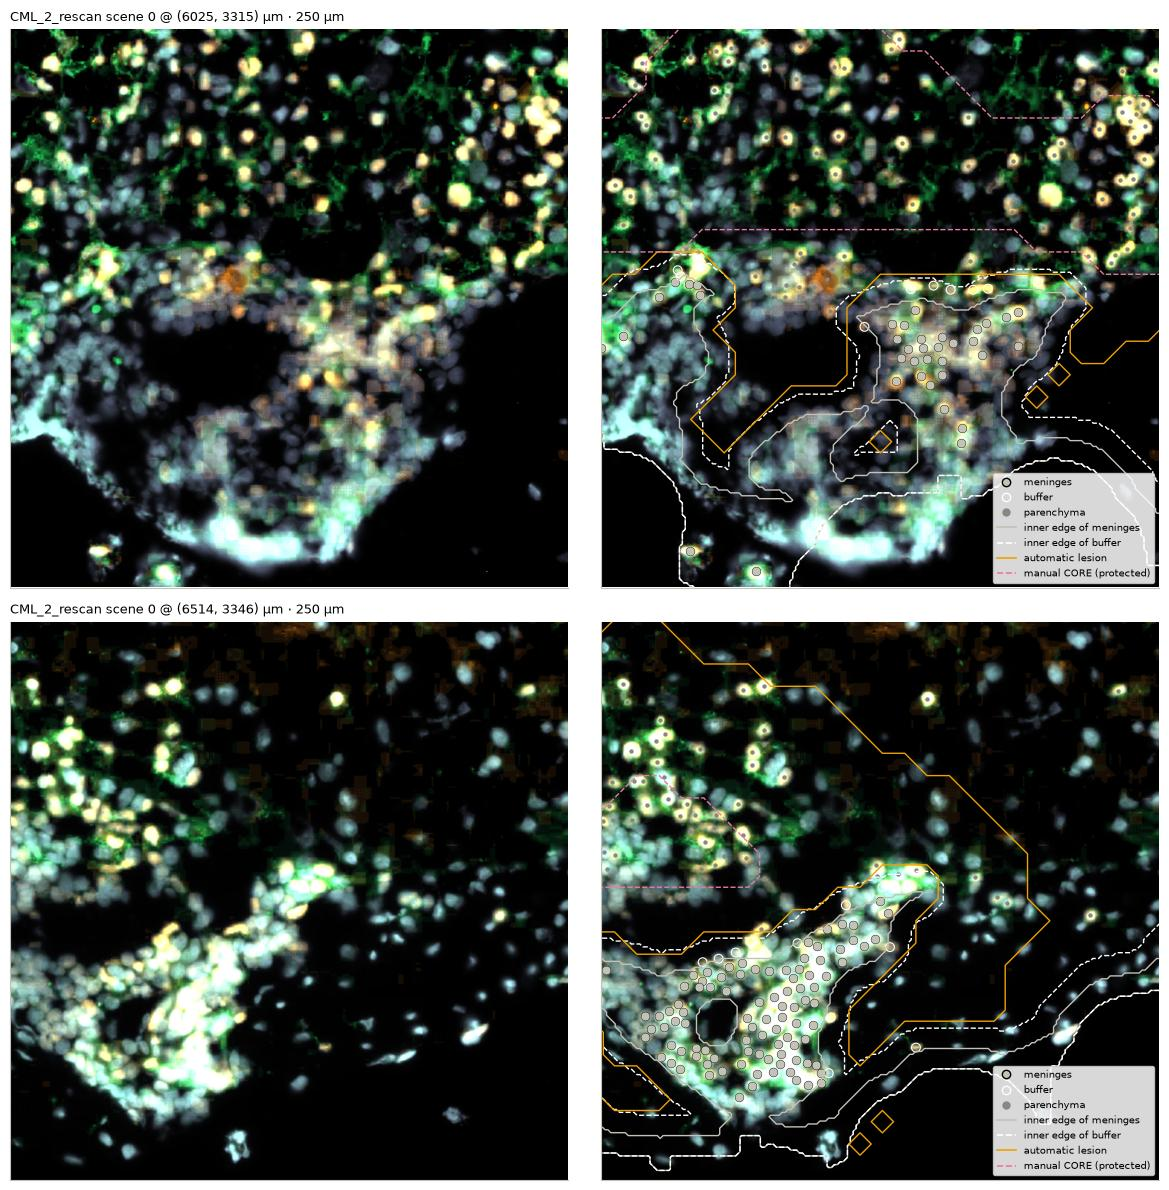

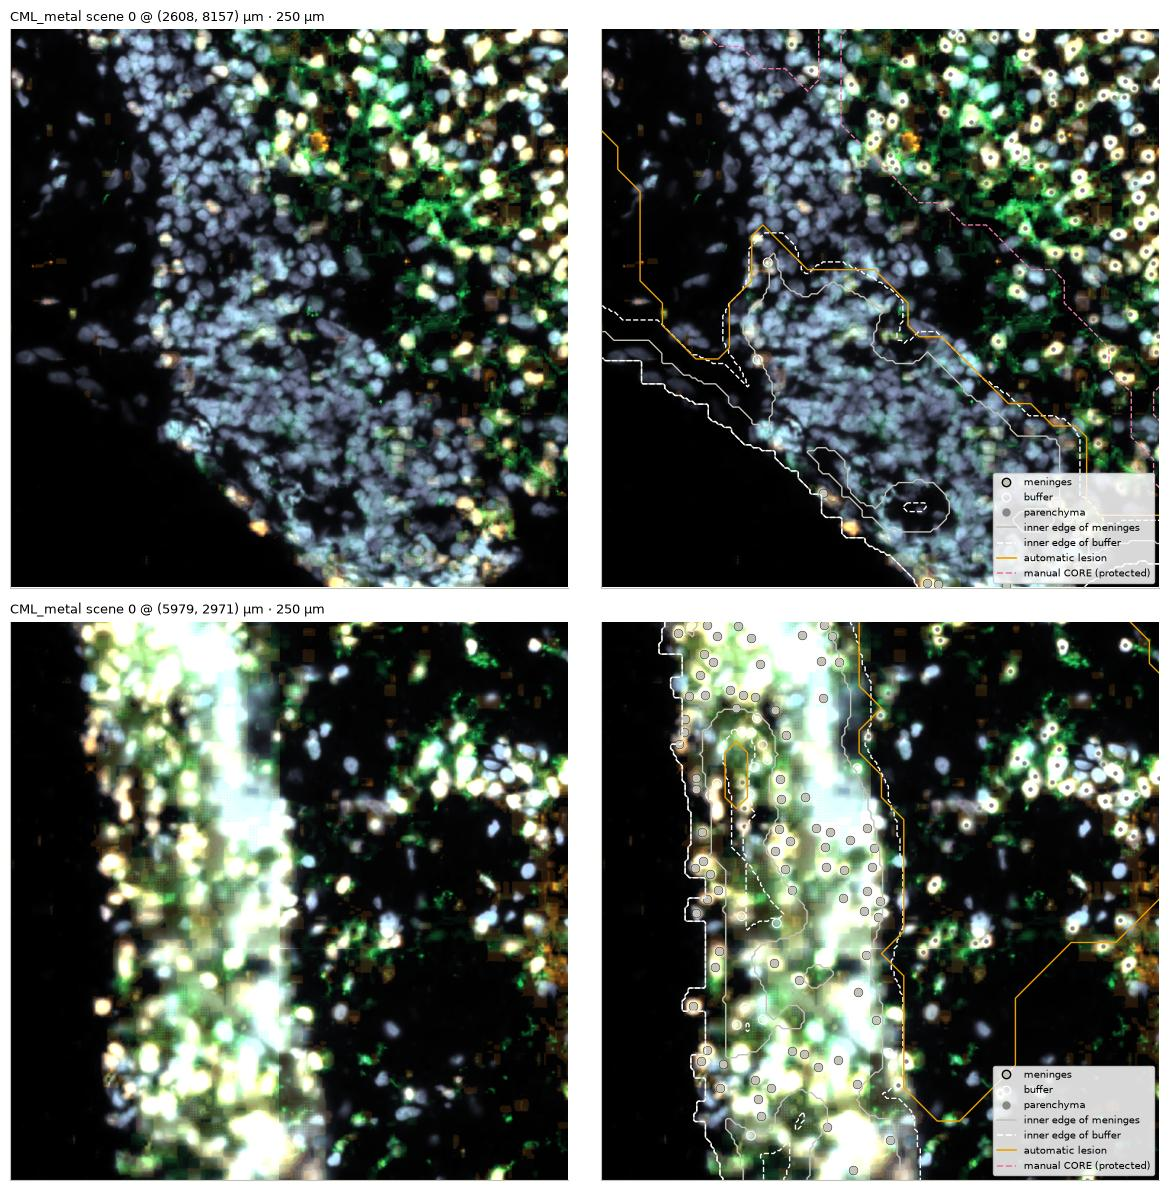

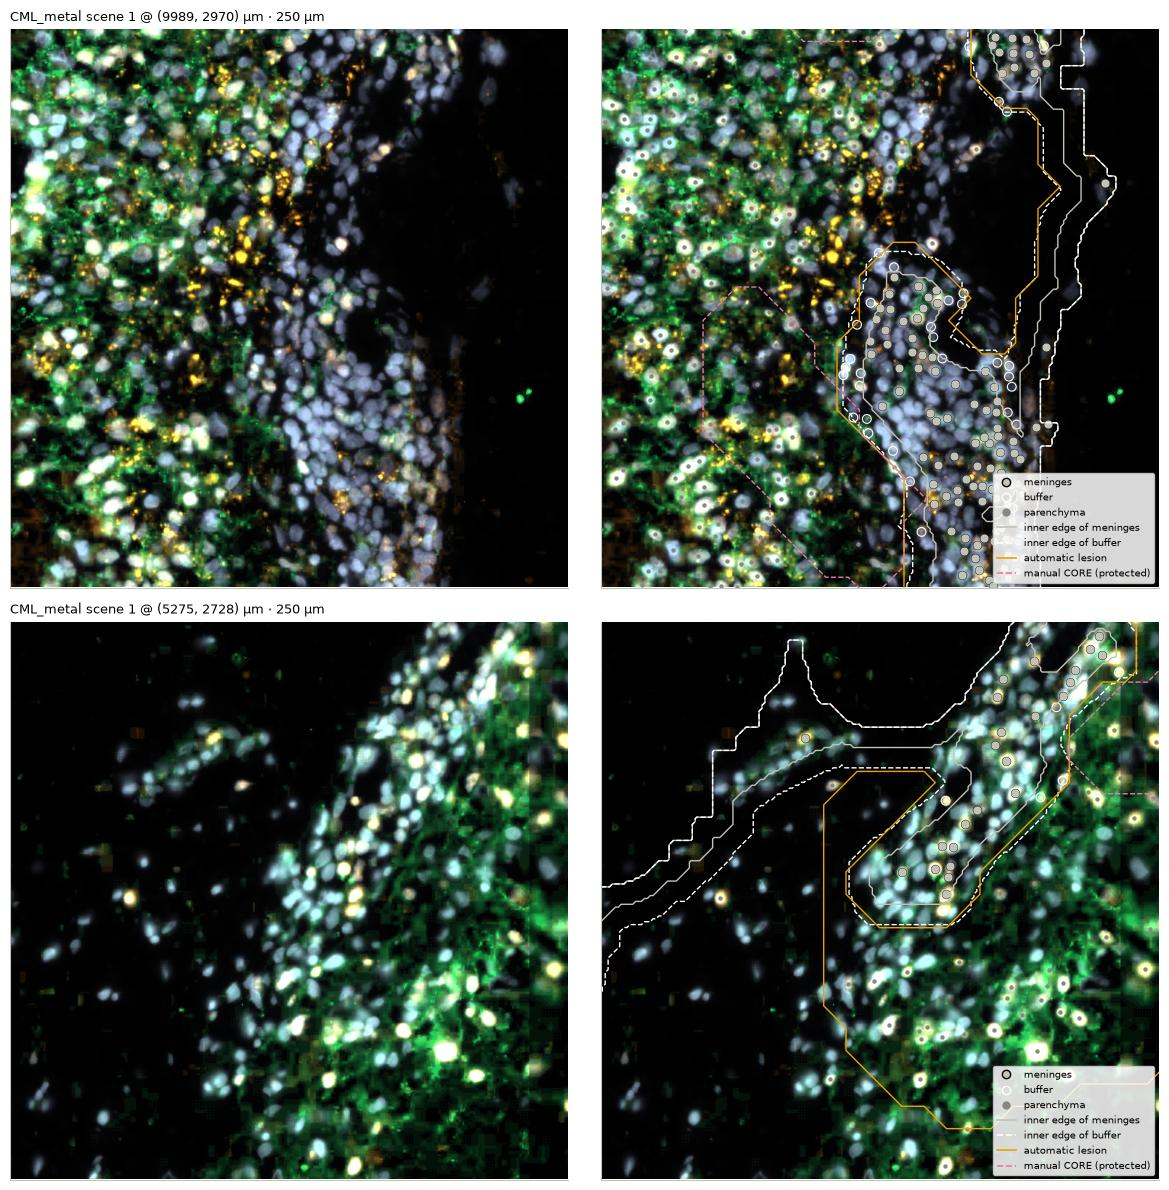

In [7]:
for r in runs:
    spots = R.thickest_meninges_spots(r, n=2)
    if not spots:
        continue
    fig, axes = plt.subplots(len(spots), 2, figsize=(12, 6 * len(spots)), squeeze=False)
    for (x, y), row in zip(spots, axes):
        R.plot_surface_zoom(r, x, y, ax=row[0], raw=True)
        R.plot_surface_zoom(r, x, y, ax=row[1])
        row[0].set_title(f"{r.name} @ ({x:.0f}, {y:.0f}) µm · 250 µm", loc="left", fontsize=9)
    plt.tight_layout(); plt.show()

## Wells actually formed (target 3000 µm² per well)

In [8]:
for r in runs:
    display(Markdown(f"### {r.name}"))
    w = r.wells
    display(w[w.well_group > 0][["section", "group", "well_group", "n_cells", "area_um2", "n_available", "note"]])
    short = w[(w.well_group == 0) | w.note.astype(str).str.startswith("short")]
    if len(short):
        display(Markdown(f"**Not filled / short:** {len(short)} of {len(w)} section×group combinations"))

### CML_1 scene 0

,section,group,well_group,n_cells,area_um2,n_available,note
7,OS1_2_,GM,1,115,2944.2,115,NaN
8,OS1_2_,WM,2,29,670.2,29,short: 670 µm²
16,OS1_2_C,GM,3,103,2990.9,201,NaN
17,OS1_2_C,WM,4,42,1265.9,42,short: 1266 µm²
25,OS1_2_L,GM,5,97,2978.1,128,NaN
26,OS1_2_L,WM,6,56,1333.3,56,short: 1333 µm²
27,P2_3_C,core,7,116,2971.6,480,NaN
28,P2_3_C,rim,8,118,2973.7,375,NaN
29,P2_3_C,ring_0_10,9,118,2986.4,425,NaN
30,P2_3_C,ring_10_20,10,107,2988.9,314,NaN


**Not filled / short:** 52 of 81 section×group combinations

### CML_2_rescan scene 0

,section,group,well_group,n_cells,area_um2,n_available,note
7,CFA_L2_C,GM,1,89,2990.7,211,NaN
8,CFA_L2_C,WM,2,34,1012.8,34,short: 1013 µm²
16,CFA_L2_L,GM,3,86,2998.2,193,NaN
17,CFA_L2_L,WM,4,29,825.3,29,short: 825 µm²
25,CFA_L2_T,GM,5,84,2297.8,84,short: 2298 µm²
26,CFA_L2_T,WM,6,16,478.6,16,short: 479 µm²
27,P3_1_C,core,7,96,2999.3,390,NaN
28,P3_1_C,rim,8,101,2965.3,543,NaN
29,P3_1_C,ring_0_10,9,95,2984.6,250,NaN
30,P3_1_C,ring_10_20,10,91,2972.0,170,NaN


...

,section,group,well_group,n_cells,area_um2,n_available,note
7,OS1_2_,GM,1,82,2991.0,105,NaN
8,OS1_2_,WM,2,16,581.3,16,short: 581 µm²
16,OS1_2_C,GM,3,91,2973.2,408,NaN
17,OS1_2_C,WM,4,37,950.8,37,short: 951 µm²
25,OS1_2_L,GM,5,78,2979.2,110,NaN
26,OS1_2_L,WM,6,17,522.1,17,short: 522 µm²
27,P2_3_C,core,7,95,2958.4,225,NaN
28,P2_3_C,rim,8,100,2996.5,343,NaN
29,P2_3_C,ring_0_10,9,108,2991.1,178,NaN
30,P2_3_C,ring_10_20,10,101,2972.8,158,NaN


**Not filled / short:** 55 of 81 section×group combinations

### CML_metal scene 1

,section,group,well_group,n_cells,area_um2,n_available,note
7,CFA_L2_C,GM,1,81,2980.1,199,NaN
8,CFA_L2_C,WM,2,32,990.5,32,short: 991 µm²
16,CFA_L2_L,GM,3,78,2971.4,283,NaN
17,CFA_L2_L,WM,4,10,351.6,10,short: 352 µm²
25,CFA_L2_T,GM,5,92,2990.6,92,NaN
26,CFA_L2_T,WM,6,8,262.6,8,short: 263 µm²
27,P3_1_C,core,7,115,2988.4,444,NaN
28,P3_1_C,rim,8,115,2990.7,477,NaN
29,P3_1_C,ring_0_10,9,108,2991.4,250,NaN
30,P3_1_C,ring_10_20,10,103,2986.6,206,NaN


**Not filled / short:** 59 of 81 section×group combinations

## Where the selected cells are

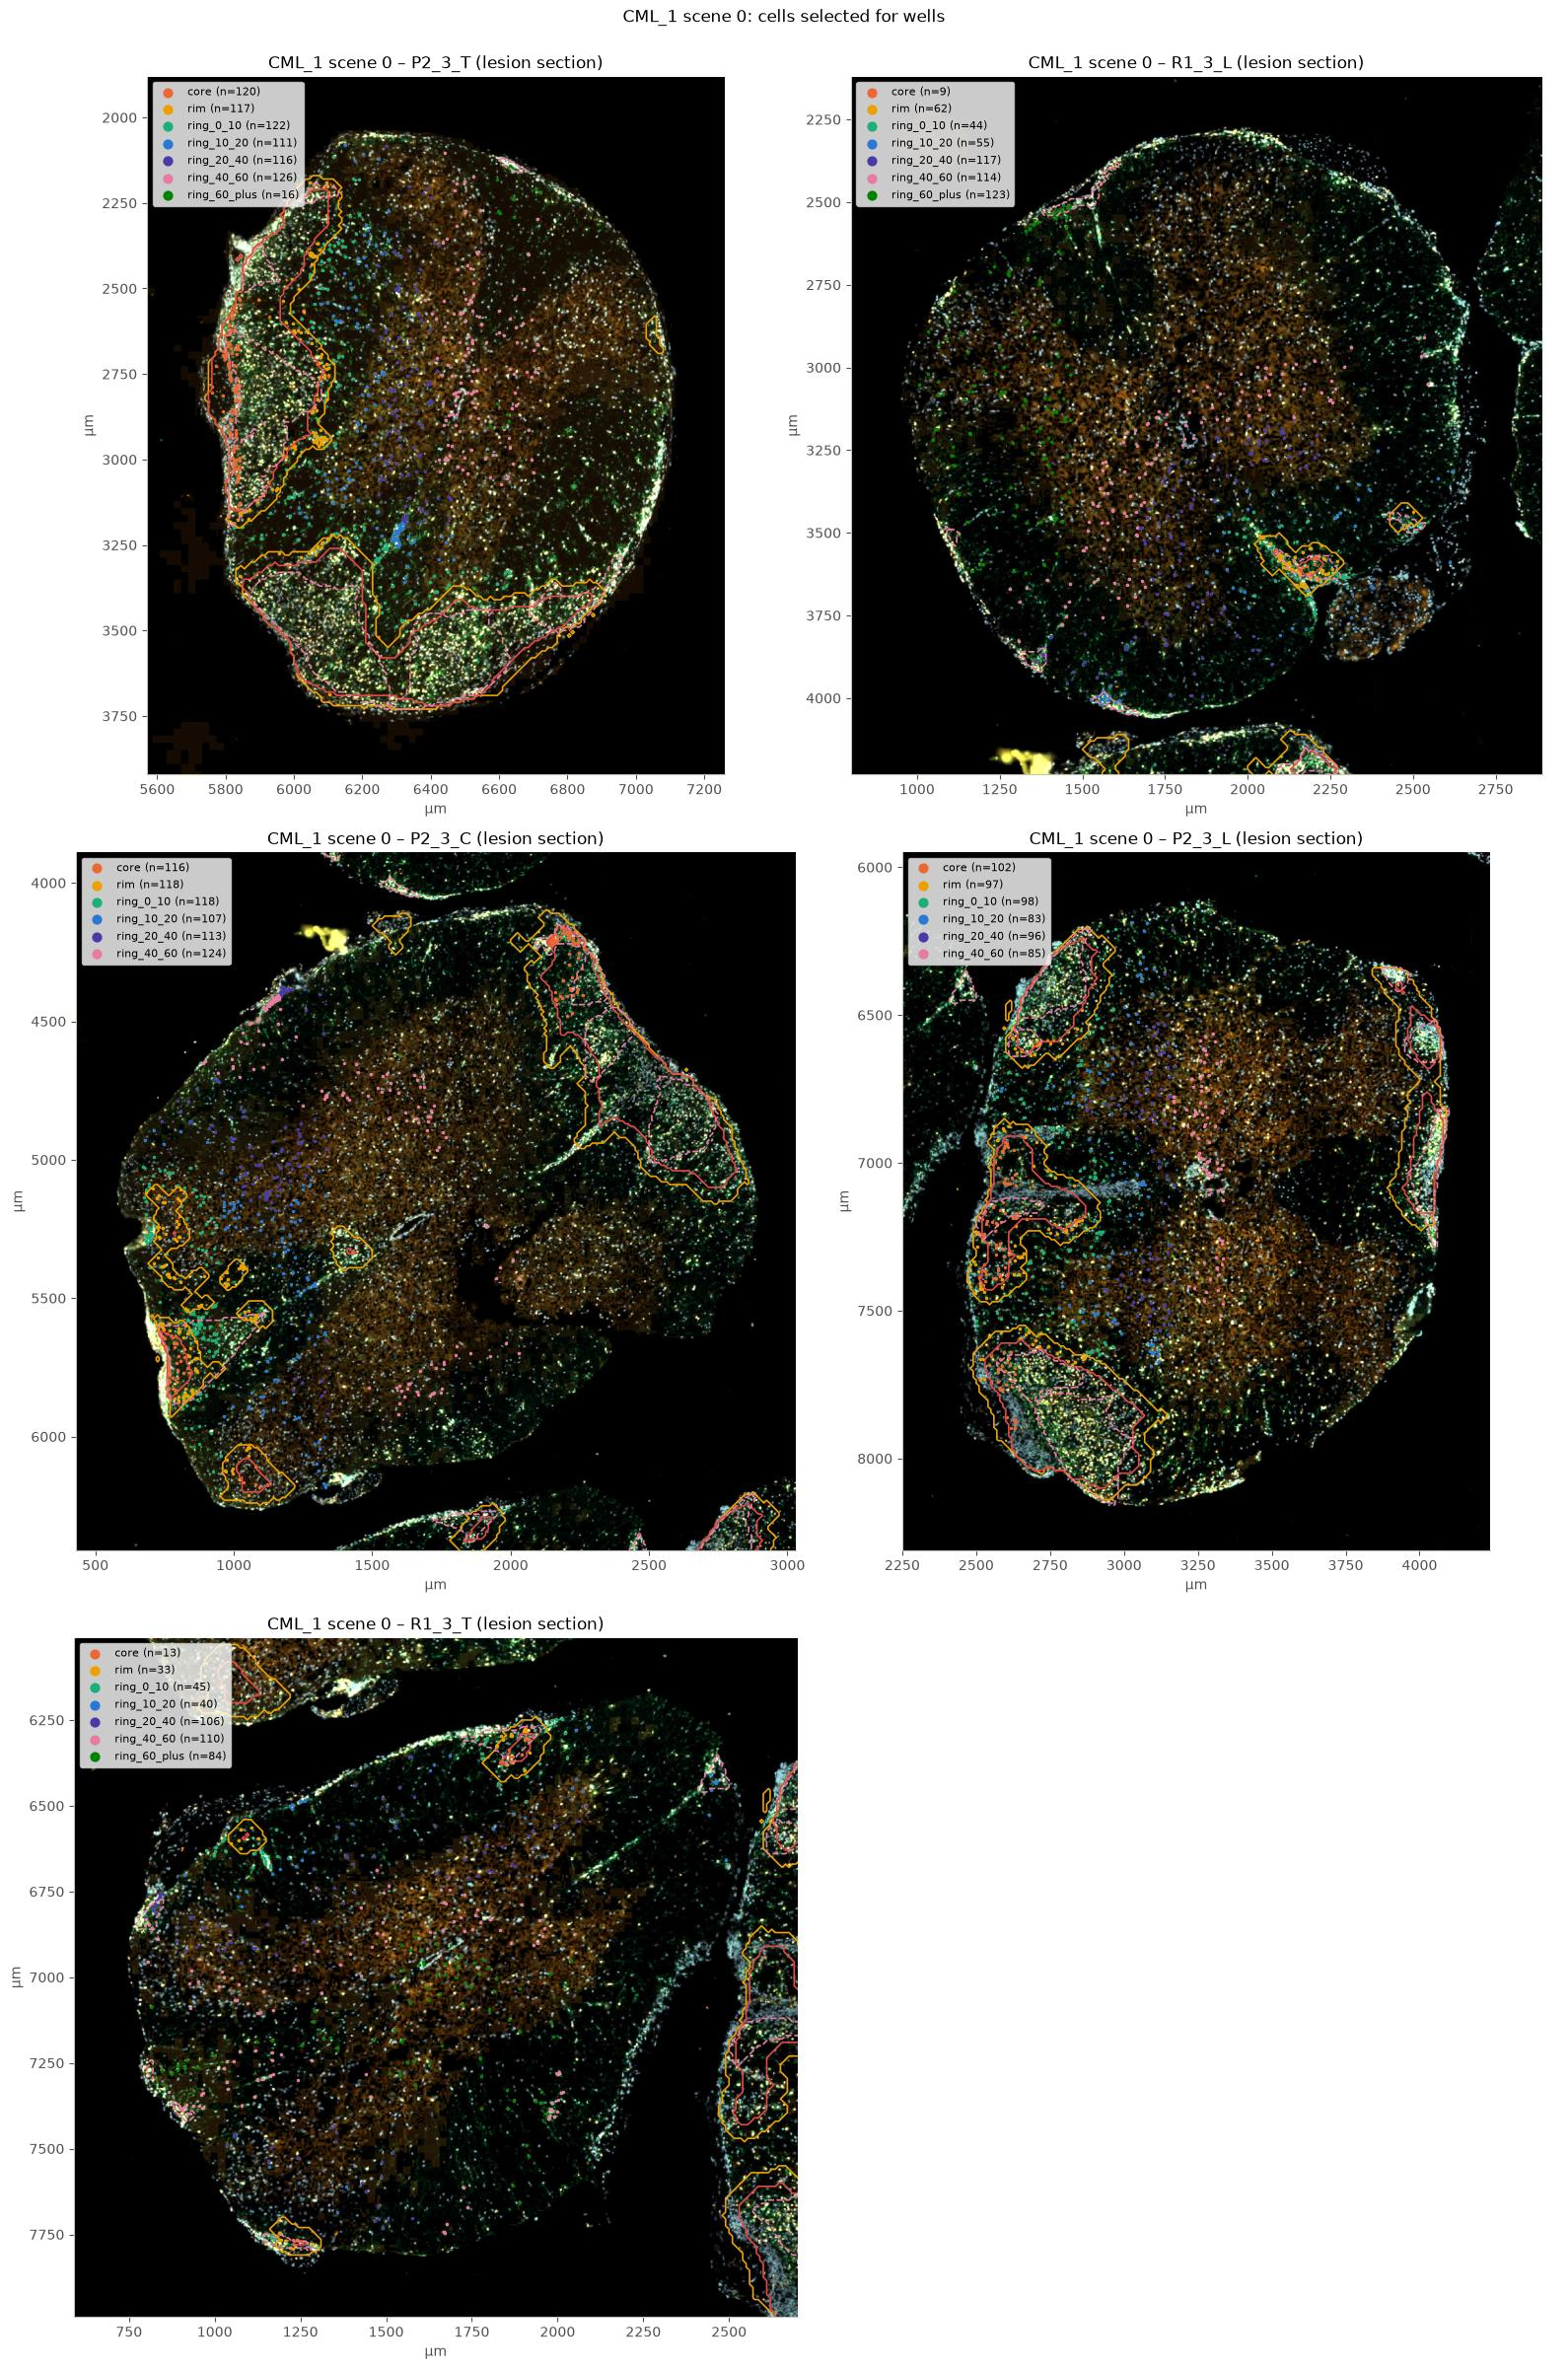

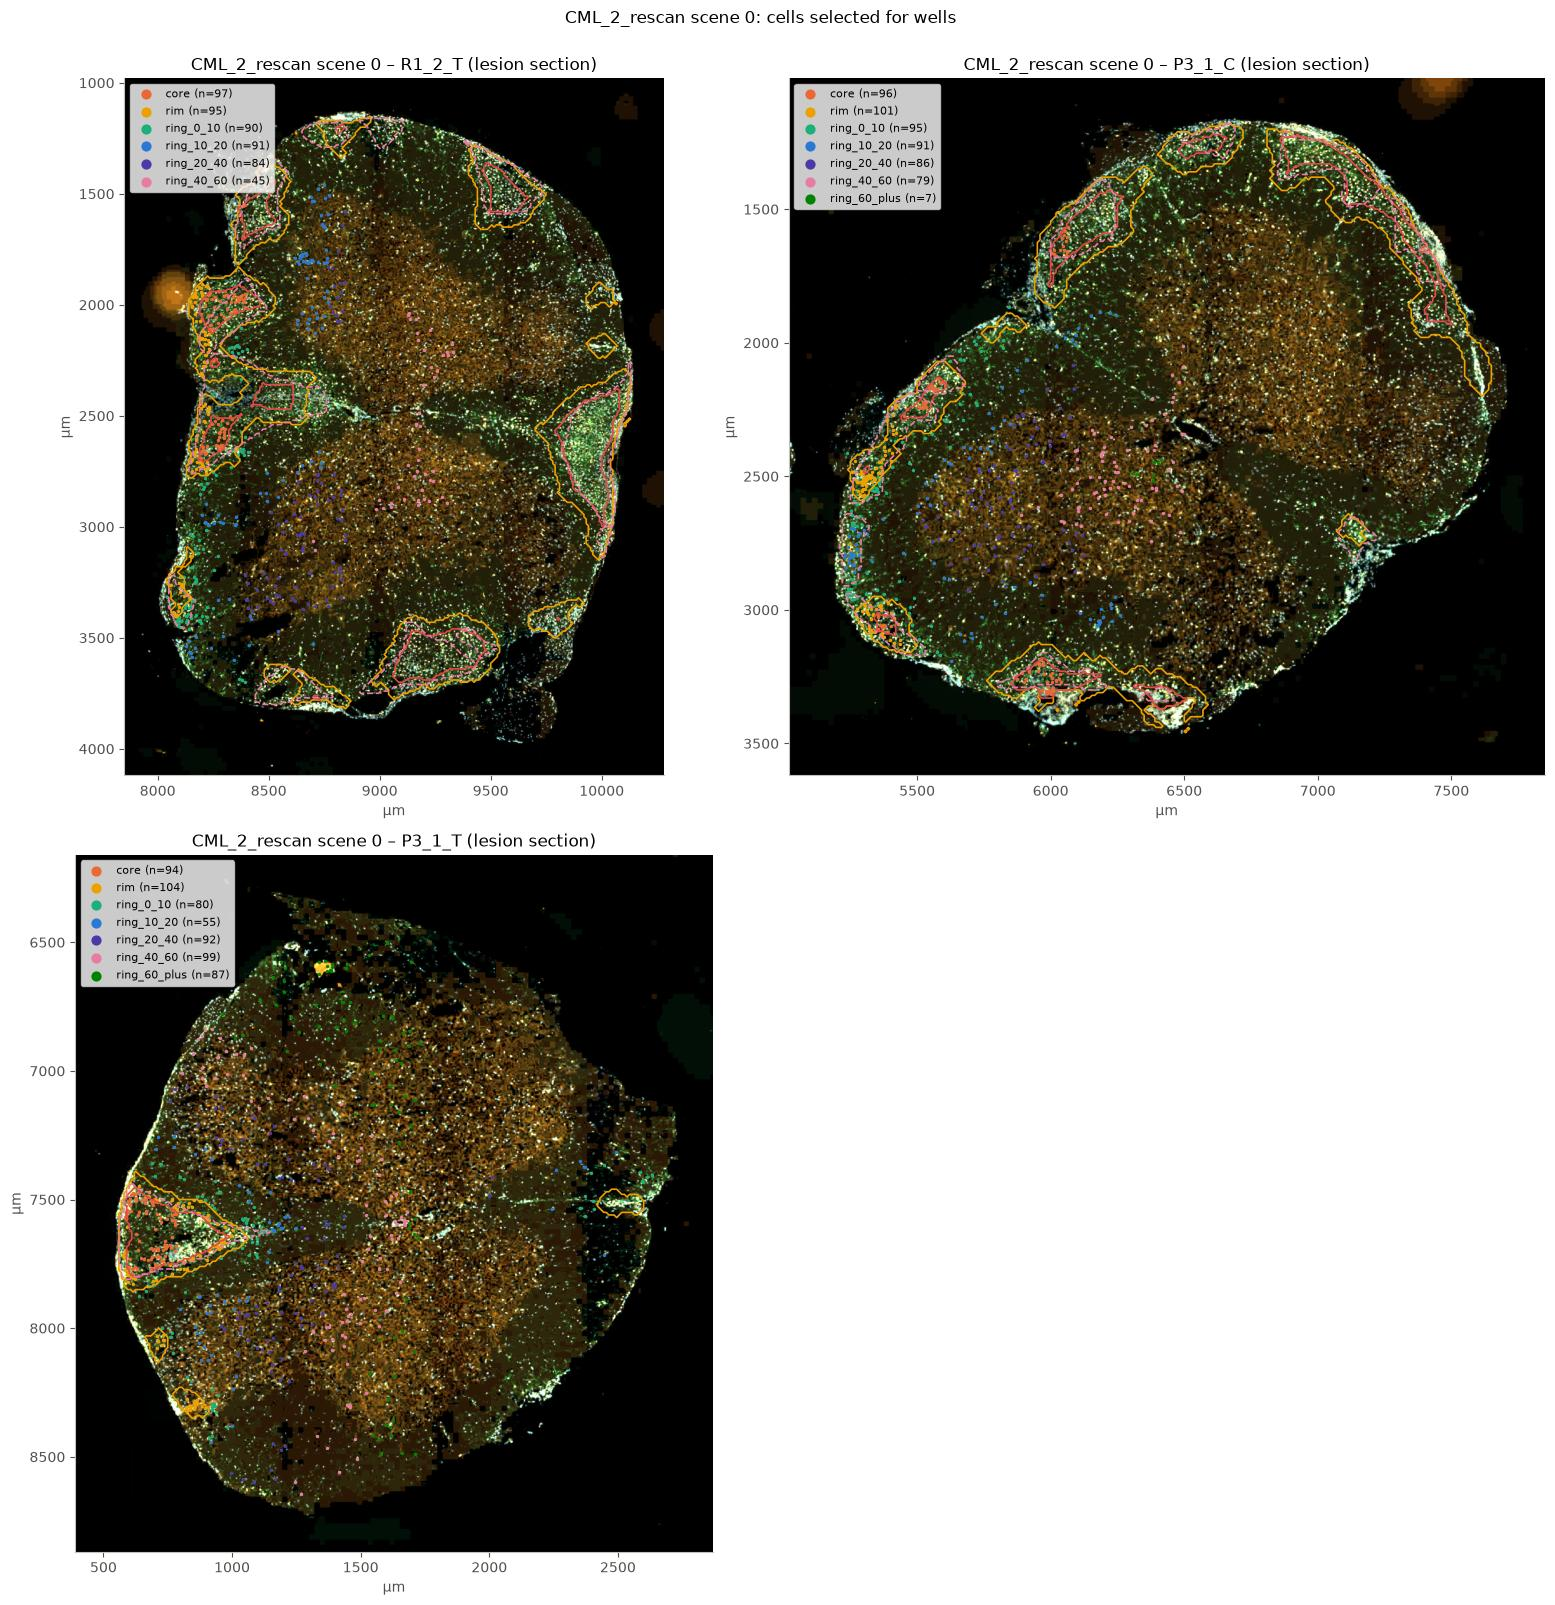

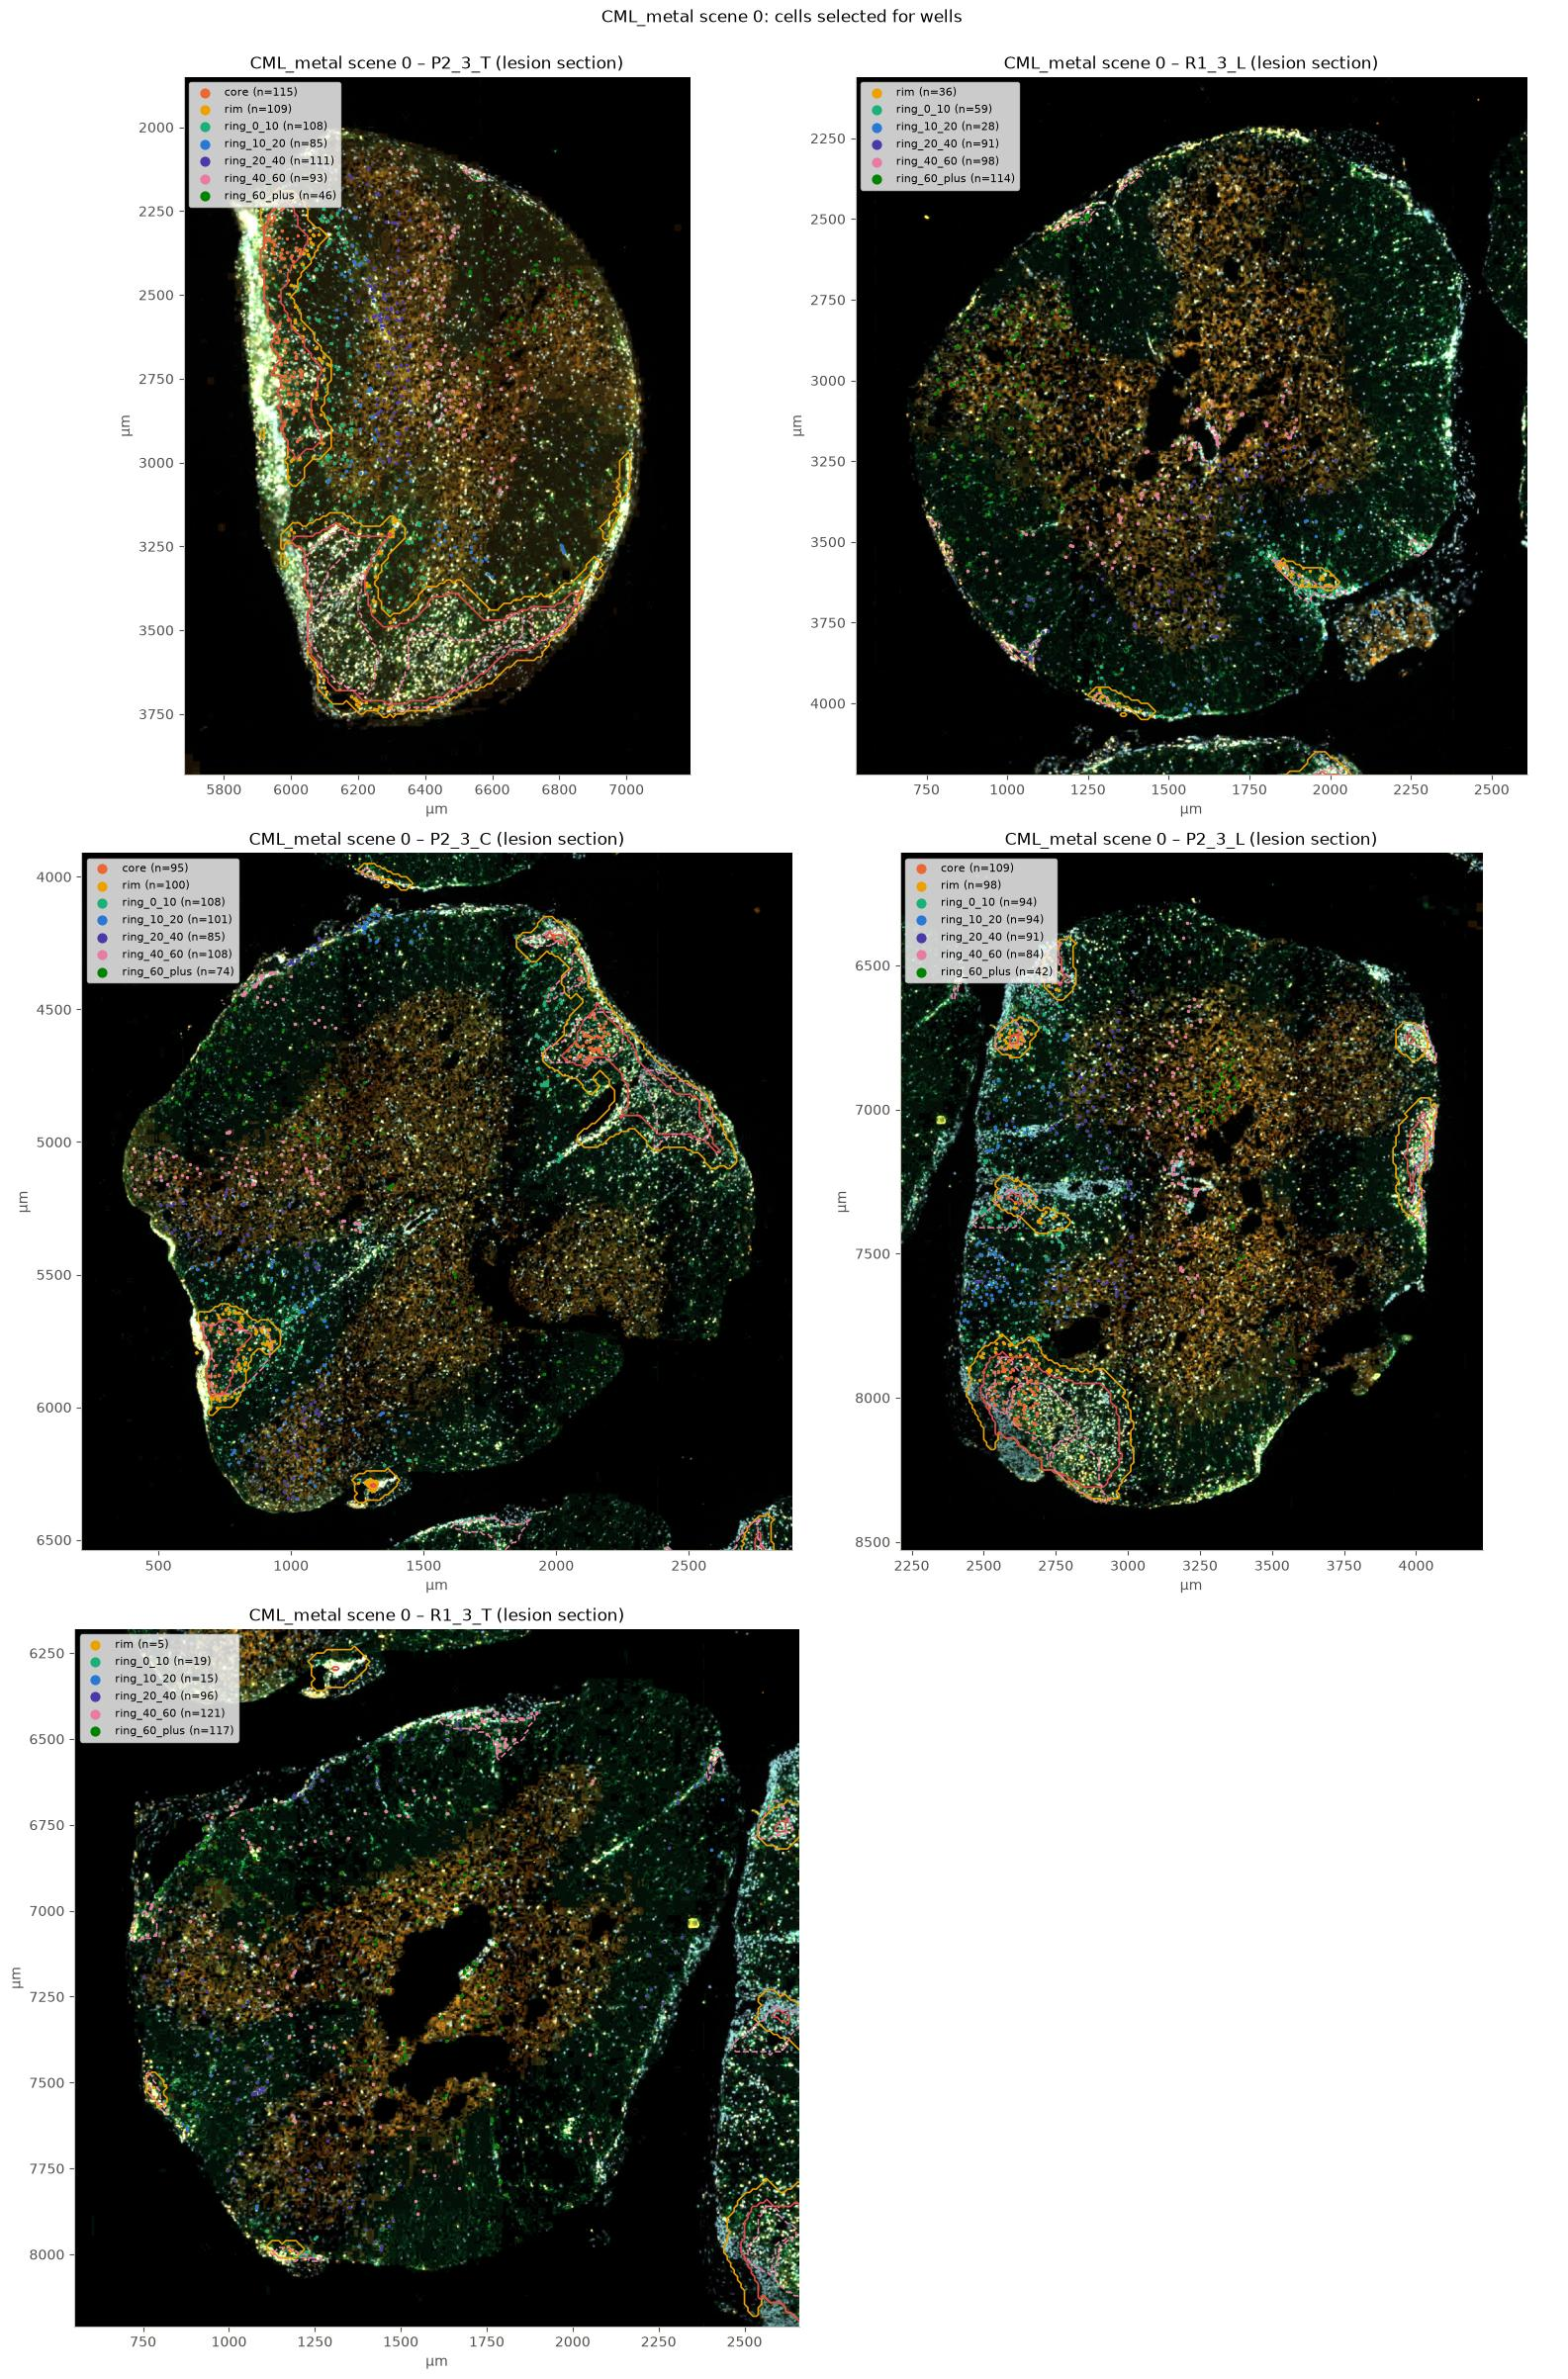

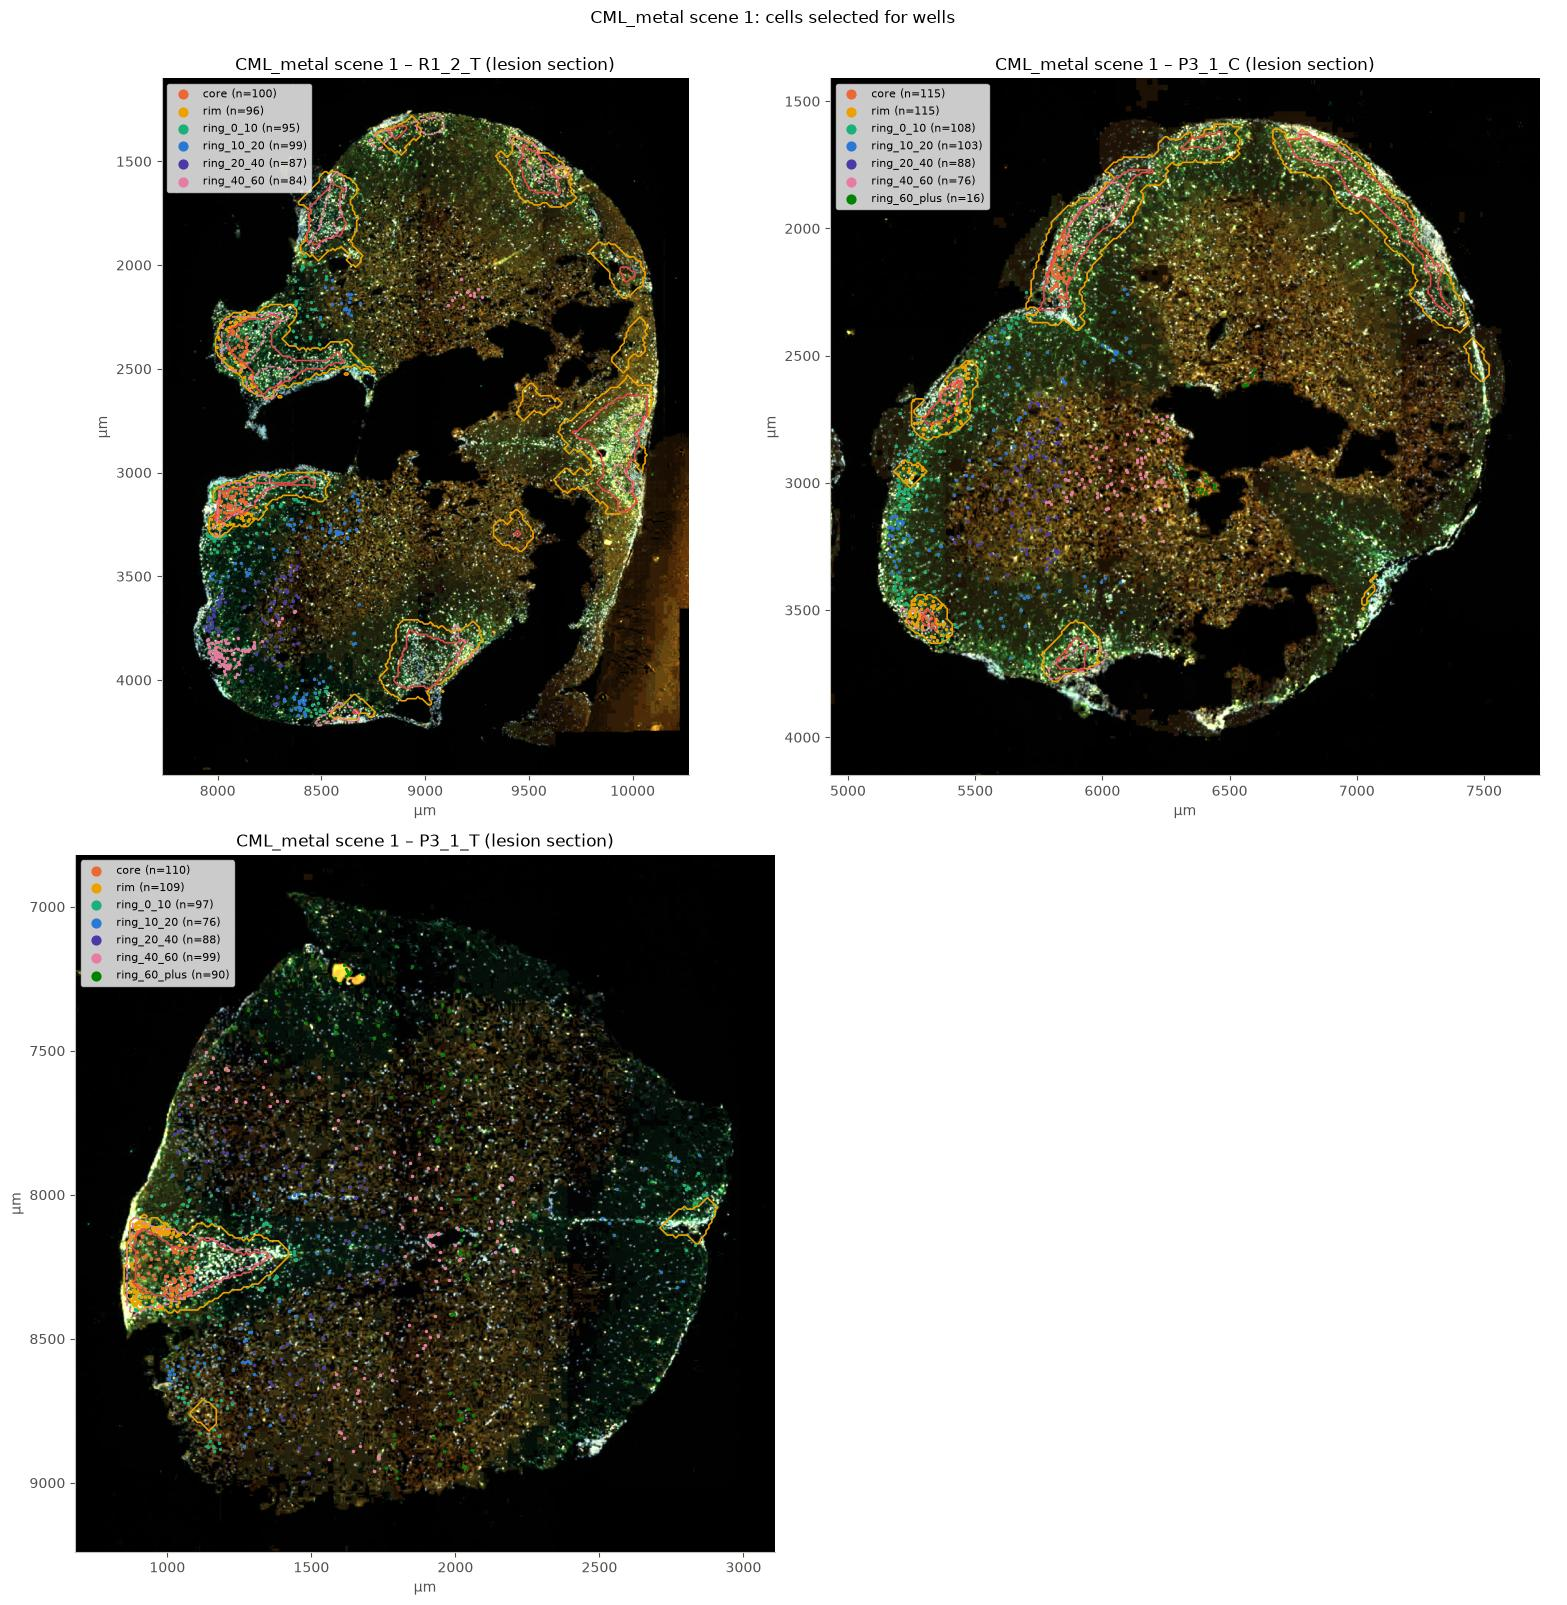

In [9]:
for r in runs:
    les = r.sections[r.sections.is_lesion_section]
    n = len(les)
    if n == 0:
        continue
    fig, axes = plt.subplots(int(np.ceil(n / 2)), 2, figsize=(16, 8 * int(np.ceil(n / 2))), squeeze=False)
    for ax, sid in zip(axes.ravel(), les.section_id):
        R.plot_section(r, int(sid), ax=ax, scale=0.2, show_cells=False)
        c = r.cells[(r.cells.section_id == sid) & (r.cells.well_group > 0)]
        for grp, s in c.groupby(c.well_name.str.split("|").str[1]):
            ax.scatter(s.x_um, s.y_um, s=6, c=R.GROUP_COLORS.get(grp, "#ffffff"), linewidths=0, label=f"{grp} (n={len(s)})")
        ax.legend(markerscale=3, fontsize=8, loc="upper left")
    for ax in axes.ravel()[n:]:
        ax.axis("off")
    fig.suptitle(f"{r.name}: cells selected for wells", y=1.0)
    plt.tight_layout(); plt.show()

## Overlap with the collaborator's own selection (`cells_selected` in the table)

In [10]:
for r in runs:
    c = r.cells
    theirs = c["cells_selected"].notna() & ~c["cells_selected"].astype(str).isin(["None", "nan"])
    display(Markdown(f"### {r.name}: collaborator selected {int(theirs.sum())} cells, this run selected {int((c.well_group > 0).sum())}; overlap {int((theirs & (c.well_group > 0)).sum())}"))
    display(pd.crosstab(c.loc[theirs, "manual_annotation"].fillna("ring (no manual label)"), c.loc[theirs, "zone"]))

### CML_1 scene 0: collaborator selected 2666 cells, this run selected 3627; overlap 1843

zone,distal,peri,rim,core,deep,meninges
manual_annotation,,,,,,
GM,382,0,0,0,0,1
WM,262,0,0,0,0,12
core,97,78,111,268,18,7
ring (no manual label),274,440,276,198,218,24


### CML_2_rescan scene 0: collaborator selected 1842 cells, this run selected 2417; overlap 1388

zone,distal,peri,rim,core,deep,meninges
manual_annotation,,,,,,
GM,444,0,0,0,0,0
WM,312,0,0,0,0,16
core,0,58,163,75,13,0
ring (no manual label),36,350,133,2,200,40


### CML_metal scene 0: collaborator selected 274 cells, this run selected 3280; overlap 175

zone,distal,peri,rim,deep,meninges
manual_annotation,,,,,
WM,71,0,0,0,9
core,18,0,0,0,2
ring (no manual label),85,44,5,40,0


### CML_metal scene 1: collaborator selected 136 cells, this run selected 2526; overlap 99

zone,distal,peri,rim,core,deep,meninges
manual_annotation,,,,,,
GM,14,0,0,0,0,0
WM,49,0,0,0,0,4
ring (no manual label),0,37,26,3,3,0


## LMD export

`lesionseg export-lmd` writes one Leica XML per scene with one well per `well_name`. It needs the
three calibration-mark coordinates in scene pixels; the demo below uses placeholders so the file
structure can be inspected.

In [11]:
from lesionseg.export import export_lmd
r = runs[0]
calib = np.array([[500, 500], [r.log["scene_shape_px"][1] - 500, 500], [500, r.log["scene_shape_px"][0] - 500]], float)  # PLACEHOLDER
out = r.dir / "demo_lmd.xml"
counts = export_lmd(r.cells, out, calibration_points_px=calib, group_col="well_name", pixel_size_um=r.px, dilate_um=1.0)
print(f"{out}: {sum(counts.values())} shapes in {len(counts)} wells")
print(out.read_text()[:600])

[50000. 50000.]
[2361700.   50000.]
[  50000. 2728100.]


outputs/sdata/CML_1/scene0/demo_lmd.xml: 3627 shapes in 41 wells
<?xml version='1.0' encoding='UTF-8'?>
<ImageData>
  <GlobalCoordinates>1</GlobalCoordinates>
  <X_CalibrationPoint_1>50000</X_CalibrationPoint_1>
  <Y_CalibrationPoint_1>50000</Y_CalibrationPoint_1>
  <X_CalibrationPoint_2>2361700</X_CalibrationPoint_2>
  <Y_CalibrationPoint_2>50000</Y_CalibrationPoint_2>
  <X_CalibrationPoint_3>50000</X_CalibrationPoint_3>
  <Y_CalibrationPoint_3>2728100</Y_CalibrationPoint_3>
  <ShapeCount>3627</ShapeCount>
  <Shape_1>
    <PointCount>209</PointCount>
    <CapID>C3</CapID>
    <X_1>1178042</X_1>
    <Y_1>482573</Y_1>
    <X_2>1178032</X_2>
    <Y_2>482582</
